<a href="https://colab.research.google.com/github/KashifMoin1410/Evans_BM_Classification/blob/main/Evans_BM_Merchant_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Merchant Text Classification

## Problem Overview

The aim of this assignment is to classify merchant descriptions into one of three labels:

| Class | Meaning |
|---|---|
| `evans` | Evans clothing retailer |
| `b & m` | B&M variety retailer |
| `other` | Any merchant that is not Evans or B&M |

The dataset contains three columns:

- `desc`: the merchant description
- `MCC`: the merchant category information
- `tag`: the target label we need to predict

In this notebook, I will first explore the data to understand the class balance, duplicates, merchant name patterns, and the usefulness of the MCC field. Then I will build a regex-based classifier and compare it with ML/NLP models.

The main questions answered are:

1. Can simple regex rules identify `evans` and `b & m`?
2. How well does the regex approach perform?
3. Can an ML/NLP model perform better?
4. Which approach is better and why?
5. Can we find hidden merchant groups inside the `other` class?

In [1]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans

import joblib

pd.set_option("display.max_colwidth", 100)
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42
LABELS = ["evans", "b & m", "other"]

## Load and Understand the data

Before any analysis, it's better to simply understand the dataset, what columns
do they have, and what does a row actually look like?

In [2]:
train_df = pd.read_csv("train_set.csv")
test_df  = pd.read_csv("test_set.csv")

print("Training Data Shape:", train_df.shape[0], "rows,", train_df.shape[1], "columns")
print("Test Data Shape:", test_df.shape[0], "rows,", test_df.shape[1], "columns\n")

Training Data Shape: 48352 rows, 3 columns
Test Data Shape: 5170 rows, 3 columns



In [3]:
display(train_df.tail())

,desc,MCC,tag
48347,amed cafe,82990 - Other business support service activities n.e.c.,other
48348,ryan davies,59113 - Television programme production activities,other
48349,affinity tankers,52220 - Service activities incidental to water transportation,other
48350,evan dresses-Limerick,5242 - Retail sale of clothing,evans
48351,k-star (old town),90020 - Support activities to performing arts,other


In [4]:
test_df.head()

,desc,MCC,tag
0,mafondos,86900 - Other human health activities,other
1,south west pat test,71200 - Technical testing and analysis,other
2,cambridge muslim college,85421 - First-degree level higher education,other
3,business ability,62020 - Information technology consultancy activities,other
4,exova group (uk),70100 - Activities of head offices,other


In [5]:
print("Attributes:", train_df.columns.tolist())

Attributes: ['desc', 'MCC', 'tag']


In [6]:
print(train_df.dtypes)

desc    object
MCC     object
tag     object
dtype: object


**What we have - three columns:**

| Column | What it is | Importance |
|--------|-----------|-----------------------|
| `desc` | A short merchant description | The labels are based on merchant names |
| `MCC`  | Merchant Category Code, which is an alpha-numeric description | May or may not help |
| `tag`  | The class label (`evans`, `b & m`, `other`) | The **target** we are predicting |

## Data Quality Checks

A model is as good as its data. It would perform well only when the data is clean and reliable. Therefore, we check for the two
most common problems:
- **missing values**,
- **duplicate rows**.

In [7]:
print('-----------------------------------')
print("Total Missing Values per Attributes:")
print('-----------------------------------')
print("Train Data:")
print(train_df.isna().sum())
print('-----------------------------------')
print("Test Data:")
print(test_df.isna().sum())

-----------------------------------
Total Missing Values per Attributes:
-----------------------------------
Train Data:
desc    0
MCC     0
tag     0
dtype: int64
-----------------------------------
Test Data:
desc    0
MCC     0
tag     0
dtype: int64


In [8]:
dup_train = train_df.duplicated().sum()
dup_test  = test_df.duplicated().sum()

perc_dup_train = dup_train/len(train_df)*100
perc_dup_test  = dup_test/len(test_df)*100

print(f"Duplicate Records in Train Data: {dup_train}")
print(f"Percentage of Duplicate Records in Train Data: {perc_dup_train:.0f}%")
print(f"\nDuplicate Records in Test Data: {dup_test}")
print(f"Percentage of Duplicate Records in Test Data: {perc_dup_test:.0f}%")

Duplicate Records in Train Data: 24176
Percentage of Duplicate Records in Train Data: 50%

Duplicate Records in Test Data: 0
Percentage of Duplicate Records in Test Data: 0%


In [9]:
# Out of these duplicate records, I also checked whether the same description has been assigned different target labels.
conflict = train_df.groupby("desc")["tag"].nunique() # .nunique() counts the number of unique tag values, not the number of rows.
print(f"\nDescriptions carrying CONFLICTING tags: {(conflict > 1).sum()}")


Descriptions carrying CONFLICTING tags: 0


**What the checks tell us:**

* **No missing values**, implying that the data is clean.
* **Around HALF the Training data are duplicates**, indicating their are only ~24k distinct rows instead of actual 48k row.
* **No Description has Conflicting tags**, so the duplicates are pure repetition, not data-quality errors.

**Why this matters, and what we do about it:** Because no description is labelled inconsistently, the duplicates are safe to remove, as they add no new information. We therefore **de-duplicate the training set**, before any cleaning or modelling.

A ML model treats a row it sees twice as twice as important, so duplicates would make training set scores look artificially optimistic and slightly distort the model. De-duplicating gives honest training metrics, faster training, and cleaner model behaviour.


**NOTE:** The test dtaa isn't touched, as it has no duplicates, and is the data the assignment asks us to be evaluated on, so it stays untouched as our honest benchmark.

In [10]:
# Removing the Duplicate Records
train_df = train_df.drop_duplicates().reset_index(drop=True)

## Understanding the target column

The single most important thing to understand before modelling is **how balanced the classes are**. This decides which performance metric is actually meaningful.

In [11]:
train_counts = train_df["tag"].value_counts()
test_counts  = test_df["tag"].value_counts()

dist = pd.DataFrame({
    "train_count": train_counts,
    "perc_train": (100 * train_counts / len(train_df)).round(1),
    "test_count": test_counts,
    "perc_test": (100 * test_counts / len(test_df)).round(1),
}).loc[LABELS] # Reorder the class counts using the predefined LABELS list

display(dist)

,train_count,perc_train,test_count,perc_test
tag,,,,
evans,1781,7.4,208,4.0
b & m,4672,19.3,542,10.5
other,17723,73.3,4420,85.5



Even after removing duplicates, the dataset is still heavily imbalanced. The `other` class dominates both train and test data, with **73.3%** in training and **85.5%** in testing.

The `evans` class is the smallest class, while `b & m` is also much smaller than `other`.

Because of this imbalance, **accuracy alone is not enough**. I will use **Macro F1-score** as the main metric because it gives equal importance to all classes.

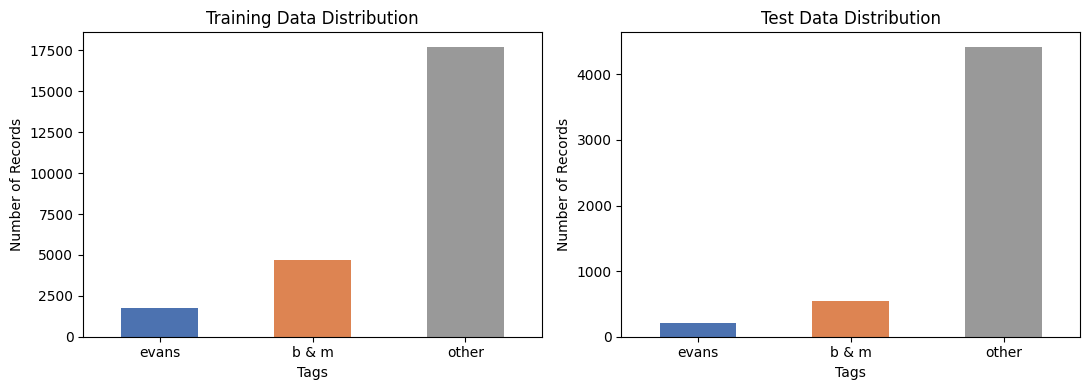

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

train_counts.loc[LABELS].plot(
    kind="bar",
    ax=axes[0],
    color=["#4C72B0", "#DD8452", "#999999"],
    title="Training Data Distribution"
)

test_counts.loc[LABELS].plot(
    kind="bar",
    ax=axes[1],
    color=["#4C72B0", "#DD8452", "#999999"],
    title="Test Data Distribution"
)

for ax in axes:
    ax.set_xlabel("Tags")
    ax.set_ylabel("Number of Records")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### The Data Is Heavily Imbalanced

The graph clearly shows that the dataset is highly imbalanced. The `other` class dominates both datasets, making up around **73%** of the training data and **85%** of the test data. In comparison, `evans` and `b & m` have much fewer records.

This matters because **accuracy can be misleading**. For example, if a model simply predicts every record as `other`, it would still get around **85% accuracy** on the test set, but it would completely fail to identify any `evans` or `b & m` merchants.

Because of this, I will use **Macro F1-score** as the main evaluation metric. Macro F1 gives equal importance to each class, regardless of how many examples it has. This is important here because we care about correctly identifying the smaller classes as well, not just the majority `other` class.

I will still report accuracy and weighted F1 for context, but the main comparison between the regex approach and the ML/NLP approach will be based on **Macro F1-score**. I will also use a confusion matrix to understand which classes the model is confusing.


**What we use instead — and why:**

| Metric | What it measures | Verdict for this task |
|--------|------------------|----------------------|
| Accuracy | overall % correct | **Misleading**, as it is dominated by the huge `other` class |
| Precision | of what we *labelled* X, how much really was X | Catches false alarms |
| Recall | of the *real* X, how much did we catch | Catches misses |
| F1 | harmonic mean of precision & recall | One balanced number |
| **Macro-F1** | the **plain average** of the three per class F1s | **Chosen headline metric** |

## Exploring the descriptions (`desc`)

`desc` is our main input, so we need to understand how it is written.

In [13]:
# Look at a random sample from EACH class.
for label in LABELS:
    print("=" * 70)
    print(f"  Sample Descriptions for: '{label}'")
    print("=" * 70)
    sample = train_df[train_df["tag"] == label]["desc"].sample(
        10, random_state=RANDOM_STATE)
    for s in sample:
        print("   ", s)
    print()

  Sample Descriptions for: 'evans'
    evns clothes-Workington
    evan fashion-St Rollox Business Par
    evan clothes-SOUTHEND
    evns fashion-Andover
    e vans clothes-Swindon
    e vans Glasgow
    evans fashion-Walsall
    evans Cambridge
    evan s fashion-Killarney
    evan dresses-York

  Sample Descriptions for: 'b & m'
    bm retail-Devon
    bnm ltd-Glasgow
    bnm ltd-County Durham
    b&m East Lothian
    bnm limited-Flintshire
    b and m bargains-County Durham
    bnm Dumfriesshire
    b&m limited-North Ayrshire
    b and m limited-Essex
    b&m retail-Cambridgeshire

  Sample Descriptions for: 'other'
    norman walsh footwear 
    lynnet leisure (properties) 
    rjd subsea consultants 
    steel dreams 
    grey visualisation 
    william cook defence 
    minerva digital marketing 
    spitfire communications 
    the yuva group 
    c d bramall york 



The brand names are spelled in many different ways. This is the central challenge.

In [14]:
# This function extracts only the brand name part from the description.
# Many descriptions follows a patter i.e. "brand name - location".
# We split the text at "-" and keep only the first part so we can focus on
# how the brand itself is written.
def brand_part(desc):
    return str(desc).split("-")[0].strip().lower()

evans_forms = train_df[train_df["tag"] == "evans"]["desc"].apply(brand_part)
bm_forms    = train_df[train_df["tag"] == "b & m"]["desc"].apply(brand_part)

In [15]:
# Words that usually appear after the Evans brand name
evans_extra_words = r"\s+(fashion|dresses|clothes|clothing|shop|store|ladies)"
evans_brand = []

for form in evans_forms:
    brand_name = re.split(evans_extra_words, form)[0]
    brand_name = brand_name.strip()
    evans_brand.append(brand_name)

evans_brand = sorted(set(evans_brand))

print("Unique EVANS spelling variants:")
for brand in evans_brand[::30]:
    print(" ",brand)

print("\nTotal Distinct Evans:", len(evans_brand))

Unique EVANS spelling variants:
  e vans
  e vans killarney
  e vans tynwald mills
  evan gateshead
  evan s basildon
  evan s leeds
  evan s tramroad side
  evans boston
  evans london
  evns
  evns leicester
  evns woolwich

Total Distinct Evans: 332


In [16]:
# Words that usually appear after the B&M brand name
bm_extra_words = r"\s+(bargains|stores?|store|retail|food|shop|ltd|limited|plc)"
bm_brand = []

for form in bm_forms:
    brand_name = re.split(bm_extra_words, form)[0]
    brand_name = brand_name.strip()
    bm_brand.append(brand_name)

bm_brand = sorted(set(bm_brand))

print("Unique B&M spelling variants:")
for brand in bm_brand[::30]:
    print(" ", brand)

print("\nTotal Distinct B&M:", len(bm_brand))

Unique B&M spelling variants:
  b &m
  b &m dunbartonshire
  b &m north yorkshire
  b and m carmarthenshire
  b and m hertfordshire
  b and m swansea
  b m gloucestershire
  b m west lothian
  b& m  dundee
  b& m  morayshire
  b&m buckinghamshire
  b&m isle of wight
  bandm bristol
  bandm greater london
  bandm south ayrshire
  bm cornwall
  bm isle of wight
  bm west lothian
  bnm east ayrshire
  bnm nottinghamshire

Total Distinct B&M: 588


There is no fixed pattern and the brand name is written in many ways, such as:

* **Evans** → `evans`, `evns`, `evan`, `e vans`, …
* **B&M** → `b m`, `b&m`, `b & m`, `b &m`, `b& m`, `bnm`, …

A basic search for the text containing the word `evans` would miss every misspelling. So our regex must be flexible and adaptive about spacing and optional letters.

### Decoy Check in the `other` tag:

I also checked whether the `other` class contains descriptions that look similar to `evans` or `b & m`. This is important because a simple regex rule may accidentally classify these records as one of the target merchants.

For example, a company name may contain the word `Evan`, but it may not be the Evans clothing retailer. Similarly, a description may contain a `B M` pattern, but it may not refer to B&M Stores.

This check helps identify potential false positives and makes the rule based approach more robust.

In [18]:
# Look only at descriptions where the true label is "other"
# We want to check whether some "other" records look similar to Evans or B&M
other_desc = train_df[train_df["tag"] == "other"]["desc"]

# In other_desc, look for 'evan'
evans_decoys = other_desc[other_desc.str.contains(r"evan", case=False, na=False)]
# In other_desc, look for 'b & m': bm, b m, b&m, b & m
bm_decoys    = other_desc[other_desc.str.contains(r"\bb ?&? ?m\b", case=False, na=False, regex=True)]

print('-'*70)
print(f"False Description for 'evans' like words: ({len(evans_decoys)} found):")
for s in evans_decoys.head(5):
    print("   ", repr(s))
print('-'*70)
print(f"False Description for 'b&m' like words:  ({len(bm_decoys)} found):")
for s in bm_decoys.head(5):
    print("   ", repr(s))

----------------------------------------------------------------------
False Description for 'evans' like words: (15 found):
    'jevans taste of india'
    'n.evans rail '
    'evans cycle'
    'burnett evans llp'
    'kevan vape store '
----------------------------------------------------------------------
False Description for 'b&m' like words:  (76 found):
    'b&m hotel'
    'b&m trading'
    'b& m  fish market'
    'b m beauty salon'
    'b& m  guitar shop'




The `other` class contains **decoys** such as `jevans taste of india`, `evans cycle`, `b&m hotel`, and `b m beauty salon`.

These are not the real target merchants, but a simple regex that searches anywhere for `evans` or `b&m` would wrongly classify them.

To reduce false positives, the regex should use **word boundaries**, check that the brand appears near the **start of the description**, and use supporting words like `fashion`, `clothes`, `store`, `bargains`, or `retail`.

Some edge cases, such as `b&m hotel` or `evans cycle` are still difficult for regex, which is why we would also test an ML/NLP approach.

## Exploring the `MCC` Field

The `MCC` field gives category information about the type of merchant. It may provide useful extra context if `evans` and `b & m` appear mostly within certain merchant categories.

Instead of assuming that `MCC` will improve the models performance, we first explore its distribution across the three classes to see whether it contains and usefull information or not.

In [19]:
print("Most Common MCC Value:")
display(train_df["MCC"].value_counts().head())

Most Common MCC Value:


,count
MCC,
46900 - Non-specialised wholesale trade,1648
47190 - Other retail sale in non-specialised stores,1630
"5139 - Non-specialised wholesale food, etc.",1562
82990 - Other business support service activities n.e.c.,1106
5142 - Wholesale of clothing and footwear,892


The `MCC` column contains both the numeric merchant category code and its text description in a single value, for example: `"47190 - Other retail sale in non-specialised stores"`.

To make this more useful, we separate it into two new fields:
- One for the numeric code
- And the other for the description.

The code can help with grouping and analysis, while the description can be used as additional text input for the ML model later.

In [20]:
def extract_mcc_code(mcc_text):
    mcc_text = str(mcc_text)
    parts = mcc_text.split(" - ")
    return parts[0].strip()

def extract_mcc_description(mcc_text):
    mcc_text = str(mcc_text)
    parts = mcc_text.split(" - ")
    if len(parts) > 1:
        return parts[1].strip()
    return "unknown"

for df in (train_df, test_df):
    df["mcc_code"]        = df["MCC"].apply(extract_mcc_code) # .apply() is used in pandas to apply a function to every value in a column
    df["mcc_desc"] = df["MCC"].apply(extract_mcc_description)

display(train_df[["MCC", "mcc_code", "mcc_desc"]].head())

,MCC,mcc_code,mcc_desc
0,41100 - Development of building projects,41100,Development of building projects
1,62012 - Business and domestic software development,62012,Business and domestic software development
2,23410 - Manufacture of ceramic household and ornamental articles,23410,Manufacture of ceramic household and ornamental articles
3,"59120 - Motion picture, video and television programme post-production activities",59120,"Motion picture, video and television programme post-production activities"
4,70100 - Activities of head offices,70100,Activities of head offices


In [21]:
print("Number of Distinct MCC Codes used by Each Class:\n")
train_df.groupby("tag")["mcc_code"].nunique()

Number of Distinct MCC Codes used by Each Class:



,mcc_code
tag,
b & m,3
evans,2
other,639


In [22]:
print("Top MCC Descriptions for 'evans':")
display(train_df[train_df["tag"] == "evans"]["mcc_desc"].value_counts())
print('-'*70)
print("Top MCC Descriptions for 'b & m':")
display(train_df[train_df["tag"] == "b & m"]["mcc_desc"].value_counts())

Top MCC Descriptions for 'evans':


,count
mcc_desc,
Retail sale of clothing,891
Wholesale of clothing and footwear,890


----------------------------------------------------------------------
Top MCC Descriptions for 'b & m':


,count
mcc_desc,
Non-specialised wholesale trade,1560
"Non-specialised wholesale food, etc.",1559
Other retail sale in non-specialised stores,1553


**What we learn from MCC**

The MCC field is useful, but it is not enough on its own.

`evans` mainly appears under clothing-related MCC descriptions such as `Retail sale of clothing` and `Wholesale of clothing and footwear`.

`b & m` mainly appears under non-specialised wholesale or retail categories.

This shows that MCC carries some useful signal. However, MCC only tells us the merchant category, not the exact merchant. For example, many clothing retailers can share the same MCC as Evans.

Therefore, the main signal for classification is still the merchant name in `desc`. We will use `desc` as the main feature, but we will also test whether adding the MCC description improves the ML model.

## Text Cleaning and Feature Engineering

Next, I prepare the text for modelling. The cleaning is kept simple because merchant descriptions are short, and some punctuation can be useful. For example, removing symbols like `&` could make it harder to identify patterns such as `b&m`.

In general NLP projects, we may perform several preprocessing steps, such as:

- Removing punctuation
- Removing stop words
- Tokenization
- Stemming
- Lemmatization
- Removing numbers or special characters
- Handling spelling mistakes
- Using n-grams
- TF-IDF vectorisation

However, for this project I do not apply aggressive preprocessing. I only lowercase the text, remove leading/trailing spaces, and collapse repeated spaces. This keeps useful merchant signals such as `&`, numbers, and brand spelling variations.

In [23]:
def text_cleaning(text):
    text = str(text).lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text

for df in (train_df, test_df):
    df["desc_cleaned"]            = df["desc"].apply(text_cleaning)
    df["mcc_desc_cleaned"] = df["mcc_desc"].apply(text_cleaning)

### Combined Text Feature

To check whether the MCC information adds value, I have created another text field by combining the cleaned merchant description with the cleaned MCC description.

Later, I will train one model using `desc_cleaned` and another using this combined text, then compare the results.

In [24]:
for df in (train_df, test_df):
    df["combined_text"] = df["desc_cleaned"] + " " + df["mcc_desc_cleaned"]

display(train_df[["desc_cleaned", "combined_text", "tag"]].head())

,desc_cleaned,combined_text,tag
0,m kavanagh,m kavanagh development of building projects,other
1,raffall,raffall business and domestic software development,other
2,joio jac,joio jac manufacture of ceramic household and ornamental articles,other
3,shark's tooth,"shark's tooth motion picture, video and television programme post-production activities",other
4,fresca group,fresca group activities of head offices,other


## Data Splitting and Evaluation Setup

Here, I define the input features (`X`) and target labels (`y`) for training and testing.

I also create reusable evaluation functions so that the regex model and ML models are compared using the same metrics.

In [25]:
X_train_desc,     X_test_desc     = train_df["desc_cleaned"],   test_df["desc_cleaned"]
X_train_combined, X_test_combined = train_df["combined_text"], test_df["combined_text"]
y_train,          y_test          = train_df["tag"],          test_df["tag"]

In [26]:
def evaluate_predictions(y_true, y_pred, model_name, dataset_name):
    accuracy    = accuracy_score(y_true, y_pred)
    macro_f1    = f1_score(y_true, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print("-" * 70)
    print(f"  {model_name}: {dataset_name} set")
    print("-" * 70)

    print(f"  Accuracy    : {accuracy:.4f}")
    print(f"  Macro-F1    : {macro_f1:.4f}")
    print(f"  Weighted-F1 : {weighted_f1:.4f}")

    print("\n  Per-class breakdown:")
    print(classification_report(y_true, y_pred, labels=LABELS, zero_division=0))
    return {"model": model_name, "dataset": dataset_name,
            "accuracy": accuracy, "macro_f1": macro_f1, "weighted_f1": weighted_f1}

## Regex-Based Classifier and Evaluation

First, I build a rule based classifier to identify `evans` and `b & m` using Regular-Expressions. Anything that does not match these rules is classified as `other`.

This section covers:

**Q1:** Build a regex/rule-based approach to classify `evans` and `b & m`.

**Q2:** Test the regex approach on the training and test sets, and explain the performance metric used.

I start with a simple regex approach, then improve it to reduce false positives from look alike descriptions.

### 1. Naive Approach

The most obvious rule: if the text contains `evans`, call it evans.

In [28]:
def naive_regex(desc):
    text = text_cleaning(desc)
    if "evans" in text:
        return "evans"
    if "b&m" in text or "b & m" in text or "b m" in text:
        return "b & m"
    return "other"

results = []
naive_train_pred = X_train_desc.apply(naive_regex)
naive_test_pred = X_test_desc.apply(naive_regex)

In [29]:
results.append(evaluate_predictions(y_train, naive_train_pred,
                                 "Naive regex", "Train"))

----------------------------------------------------------------------
  Naive regex: Train set
----------------------------------------------------------------------
  Accuracy    : 0.7876
  Macro-F1    : 0.5150
  Weighted-F1 : 0.7331

  Per-class breakdown:
              precision    recall  f1-score   support

       evans       0.96      0.18      0.31      1781
       b & m       0.96      0.22      0.36      4672
       other       0.78      1.00      0.87     17723

    accuracy                           0.79     24176
   macro avg       0.90      0.47      0.51     24176
weighted avg       0.83      0.79      0.73     24176



In [30]:
results.append(evaluate_predictions(y_test, naive_test_pred,
                                 "Naive regex", "Test"))

----------------------------------------------------------------------
  Naive regex: Test set
----------------------------------------------------------------------
  Accuracy    : 0.8911
  Macro-F1    : 0.5793
  Weighted-F1 : 0.8648

  Per-class breakdown:
              precision    recall  f1-score   support

       evans       0.87      0.22      0.35       208
       b & m       0.93      0.30      0.45       542
       other       0.89      1.00      0.94      4420

    accuracy                           0.89      5170
   macro avg       0.89      0.50      0.58      5170
weighted avg       0.89      0.89      0.86      5170



In [31]:
# Find records where the naive regex prediction is different from the true label
train_df["naive_prediction"] = naive_train_pred
naive_errors = train_df[train_df["tag"] != train_df["naive_prediction"]].copy()
print(f"Number of wrong predictions on training set: {len(naive_errors):,}")

Number of wrong predictions on training set: 5,136


In [32]:
# False positives:
# Records that are actually "other", but the naive regex predicted evans or b & m
false_positives = naive_errors[naive_errors["tag"] == "other"].copy()
false_positives["naive_prediction"] = false_positives["desc"].apply(naive_regex)

display(false_positives[["desc", "tag", "naive_prediction"]].head())

,desc,tag,naive_prediction
154,c b mullen,other,b & m
160,b&m hotel,other,b & m
263,b&m trading,other,b & m
1012,b m beauty salon,other,b & m
1195,b&m chicken,other,b & m


In [33]:
# False negatives:
# Records that are actually evans or b & m, but the naive regex failed to predict them correctly
false_negatives = naive_errors[naive_errors["tag"] != "other"].copy()
false_negatives["naive_prediction"] = false_negatives["desc"].apply(naive_regex)

display(false_negatives[["desc", "tag", "naive_prediction"]].head())

,desc,tag,naive_prediction
7,bnm bargains-North Lincolnshire,b & m,other
10,b and m ltd-Monmouthshire,b & m,other
11,evns fashion-Boston,evans,other
22,bm ltd-Mid Glamorgan,b & m,other
23,bnm food store-Oxfordshire,b & m,other


**The naive regex makes two main types of mistakes:**

- **False positives**: It wrongly matches look alike merchants such as `evans cycle`, `bevan investments`, or `b&m hotel`, because it searches for the brand text too broadly.
- **False negatives**: It misses spelling variations such as `evns`, `bnm`, or `bandm`, because the rules are too basic.

The next step is to improve the regex so it is stricter with false positives and more flexible with known spelling variations.

### 2. Updated Regex

After checking the naive regex mistakes, I made the rules more careful.

The updated regex avoids matching brand names inside longer words, so examples like `jevans` or `kevan` are less likely to be wrongly classified as `evans`.

It also includes the spelling variations we saw in the data, such as `evns`, `evan`, `bnm`, and `bandm`, so the regex does not only depend on the perfect spelling.

I use `re.VERBOSE` because it lets me write the regex across multiple lines, making it easier to read, explain, and maintain.

In [34]:
def updated_regex(desc):
    text = text_cleaning(desc)

    # b&m Pattern
    b_and_m_pattern = r'''
        (?<![a-z0-9])
        ( b\s*&\s*m | b\s+and\s+m | b\s+m | bnm | bandm )
        (?![a-z0-9])
    '''

    bm_pattern = r'''
        (?<![a-z0-9]) bm
        (?=\s*(bargains|stores?|retail|food|limited|ltd|-|$))
    '''
    # evans Pattern
    evans_pattern = r'''
        (?<![a-z0-9])
        ( evans | evns | e\s*v\s*a?n\s*s? )
        (?![a-z0-9])
    '''

    if re.search(b_and_m_pattern, text, flags=re.VERBOSE):
        return "b & m"
    if re.search(bm_pattern, text, flags=re.VERBOSE):
        return "b & m"
    if re.search(evans_pattern, text, flags=re.VERBOSE):
        return "evans"
    return "other"

### Evaluating the Updated Regex

Next, I apply the improved regular expressions to both the training and test sets.

The main metric used is **Macro F1-score** because the classes are imbalanced.

In [35]:
train_df["updated_regex_pred"] = X_train_desc.apply(updated_regex)
test_df["updated_regex_pred"]  = X_test_desc.apply(updated_regex)

In [36]:
results.append(evaluate_predictions(y_train, train_df["updated_regex_pred"],
                                    "Updated Rule-Based Regex", "Train"))

----------------------------------------------------------------------
  Updated Rule-Based Regex: Train set
----------------------------------------------------------------------
  Accuracy    : 0.9921
  Macro-F1    : 0.9909
  Weighted-F1 : 0.9921

  Per-class breakdown:
              precision    recall  f1-score   support

       evans       0.99      1.00      1.00      1781
       b & m       0.98      0.98      0.98      4672
       other       1.00      0.99      0.99     17723

    accuracy                           0.99     24176
   macro avg       0.99      0.99      0.99     24176
weighted avg       0.99      0.99      0.99     24176



In [37]:
results.append(evaluate_predictions(y_test,  test_df["updated_regex_pred"],
                                    "Updated Rule-Based Regex", "Test"))

----------------------------------------------------------------------
  Updated Rule-Based Regex: Test set
----------------------------------------------------------------------
  Accuracy    : 0.9934
  Macro-F1    : 0.9850
  Weighted-F1 : 0.9935

  Per-class breakdown:
              precision    recall  f1-score   support

       evans       0.97      1.00      0.98       208
       b & m       0.97      0.98      0.98       542
       other       1.00      0.99      1.00      4420

    accuracy                           0.99      5170
   macro avg       0.98      0.99      0.98      5170
weighted avg       0.99      0.99      0.99      5170



### Updated Regex Results

The updated regex performs very well on both train and test data.

It achieves a **Macro F1-score of 0.9909** on the training set and **0.9850** on the test set. This shows that the rules work well across all three classes, not just the majority `other` class.

The train and test scores are also very close, which suggests the regex generalises well. However, since the rules are manually written, they may still miss new or unusual spelling variations. Let's have a look at some instances.

In [38]:
updated_regex_errors = test_df[
    test_df["tag"] != test_df["updated_regex_pred"]
].copy()

print(f"Number of wrong predictions on Test Set: {len(updated_regex_errors):,}")

Number of wrong predictions on Test Set: 34


In [39]:
# False positives:
# Records that are actually "other", but the updated regex predicted evans or b & m
updated_false_positives = updated_regex_errors[
    updated_regex_errors["tag"] == "other"
].copy()

display(
    updated_false_positives[
        ["desc", "tag", "updated_regex_pred"]
    ].head()
)

,desc,tag,updated_regex_pred
631,bandm salon,other,b & m
776,b m lawyers,other,b & m
934,b& m bm vegan food,other,b & m
1645,bnm guitar shop,other,b & m
1940,b &m bakery,other,b & m


In [40]:
# False negatives:
# Records that are actually evans or b & m, but the updated regex predicted them incorrectly
updated_false_negatives = updated_regex_errors[
    updated_regex_errors["tag"] != "other"
].copy()

display(
    updated_false_negatives[
        ["desc", "tag", "updated_regex_pred"]
    ].head()
)

,desc,tag,updated_regex_pred
119,bm Aberdeen,b & m,other
323,bm Swansea,b & m,other
843,bm South Lanarkshire,b & m,other
1217,bm Mid Glamorgan,b & m,other
1456,bm Tyne and Wear,b & m,other


## Can ML/NLP Do Better?

**Q3:** Can we improve the regex approach using ML/NLP tools, and evaluate the performance on both train and test sets?

So far, the regex approach is based on manually written rules. Now I will test whether an ML/NLP model can learn these patterns automatically from the labelled data.

For text classification, the text first needs to be converted into numbers. I will use **TF-IDF character n-grams** because merchant names are short and often have spelling variations. This works well for examples like `evans`, `evns`, `e vans`, `b&m`, `bnm`, and `bandm`.

For the ML/NLP approach, I test simple but strong text classification models:

1. **TF-IDF Character N-Grams + Logistic Regression**  
   This is a strong baseline for text classification. Character n-grams are useful because they can handle spelling variations such as `evans`, `evns`, `e vans`, `b&m`, `bnm`, and `bandm`.

2. **TF-IDF Character N-Grams + Logistic Regression with MCC**  
   This tests whether adding the MCC description gives extra information beyond the merchant description.

3. **TF-IDF Character N-Grams + Linear SVM**  
   Linear SVM is often very strong for text classification, especially with TF-IDF features. I use it as a second ML model to compare against Logistic Regression.

I am not using deep learning models here because the dataset is relatively small, the text is short, and the current problem can be solved well with simpler, more explainable models.

### Alternatives Considered

Before choosing TF-IDF character n-grams, I considered a few other approaches:

- **Word level TF-IDF**: is useful for normal text classification, but less suitable here because misspellings like `evans`, `evns`, and `e vans` would be treated as different words.

- **Bag of Words** is simple, but it depends heavily on exact word matches and does not handle spelling variations well.

- **Stemming/Lemmatization** are useful for normal words, but not very helpful for brand names. It may also change merchant names in unwanted ways.

- **Word embeddings, such as Word2Vec or GloVe**: are very useful when word meaning matters, as they do take semantic meaning into consideration.

- **Transformer models, such as BERT** are very powerful, but too heavy for this task. The descriptions are short, and can be solved well with simpler models.

For this reason, I use **TF-IDF character n-grams**. They work well with short, messy merchant names because they learn small character patterns such as `eva`, `van`, `b&m`, `bnm`, and `andm`.

### Model 1: TF-IDF character n-grams + Logistic Regression (`desc` only)

In [41]:
logreg_desc_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=3,
        max_features=35000
    )),
    ("classifier", LogisticRegression(
        # Logistic Regression adjusts its weights gradually, and the default iterations may be insufficient,
        # particularly with large feature spaces like TF-IDF character n-grams.
        # Increasing the iterations to 1000 helps the model converge effectively.
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])
logreg_desc_model.fit(X_train_desc, y_train)

logreg_desc_train_pred = logreg_desc_model.predict(X_train_desc)
logreg_desc_test_pred = logreg_desc_model.predict(X_test_desc)

In [42]:
results.append(evaluate_predictions(y_train, logreg_desc_train_pred,
                                    "Logistic Regression + TF-IDF Char N-Grams (Description Only)", "Train"))

----------------------------------------------------------------------
  Logistic Regression + TF-IDF Char N-Grams (Description Only): Train set
----------------------------------------------------------------------
  Accuracy    : 0.9985
  Macro-F1    : 0.9974
  Weighted-F1 : 0.9985

  Per-class breakdown:
              precision    recall  f1-score   support

       evans       0.99      1.00      1.00      1781
       b & m       1.00      1.00      1.00      4672
       other       1.00      1.00      1.00     17723

    accuracy                           1.00     24176
   macro avg       1.00      1.00      1.00     24176
weighted avg       1.00      1.00      1.00     24176



In [43]:
results.append(evaluate_predictions(y_test, logreg_desc_test_pred,
                                    "Logistic Regression + TF-IDF Char N-Grams (Description Only)", "Test"))

----------------------------------------------------------------------
  Logistic Regression + TF-IDF Char N-Grams (Description Only): Test set
----------------------------------------------------------------------
  Accuracy    : 0.9969
  Macro-F1    : 0.9893
  Weighted-F1 : 0.9969

  Per-class breakdown:
              precision    recall  f1-score   support

       evans       0.95      1.00      0.97       208
       b & m       0.99      1.00      1.00       542
       other       1.00      1.00      1.00      4420

    accuracy                           1.00      5170
   macro avg       0.98      1.00      0.99      5170
weighted avg       1.00      1.00      1.00      5170



### Model 2: Adding MCC Description

In this model, I use both the merchant description and the MCC description together.

The aim is to check whether MCC adds useful extra information, rather than assuming it will help. This lets us compare `desc` only versus `desc + MCC description` fairly.

In [44]:
logreg_combined_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=3,
        max_features=35000
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

logreg_combined_model.fit(X_train_combined, y_train)

logreg_combined_train_pred = logreg_combined_model.predict(X_train_combined)
logreg_combined_test_pred = logreg_combined_model.predict(X_test_combined)

In [45]:
results.append(evaluate_predictions(y_train,logreg_combined_train_pred,
        "Logistic Regression + TF-IDF Char N-Grams using Description + MCC", "Train"))

----------------------------------------------------------------------
  Logistic Regression + TF-IDF Char N-Grams using Description + MCC: Train set
----------------------------------------------------------------------
  Accuracy    : 0.9942
  Macro-F1    : 0.9913
  Weighted-F1 : 0.9942

  Per-class breakdown:
              precision    recall  f1-score   support

       evans       0.98      1.00      0.99      1781
       b & m       0.98      1.00      0.99      4672
       other       1.00      0.99      1.00     17723

    accuracy                           0.99     24176
   macro avg       0.99      1.00      0.99     24176
weighted avg       0.99      0.99      0.99     24176



In [46]:
results.append(evaluate_predictions(y_test,logreg_combined_test_pred,
        "Logistic Regression + TF-IDF Char N-Grams using Description + MCC", "Test"))

----------------------------------------------------------------------
  Logistic Regression + TF-IDF Char N-Grams using Description + MCC: Test set
----------------------------------------------------------------------
  Accuracy    : 0.9911
  Macro-F1    : 0.9783
  Weighted-F1 : 0.9912

  Per-class breakdown:
              precision    recall  f1-score   support

       evans       0.94      1.00      0.97       208
       b & m       0.94      1.00      0.97       542
       other       1.00      0.99      0.99      4420

    accuracy                           0.99      5170
   macro avg       0.96      1.00      0.98      5170
weighted avg       0.99      0.99      0.99      5170



### Model 3: Linear SVM

For the third model, I use the same TF-IDF character n-gram features, but change the classifier from Logistic Regression to Linear SVM.

Linear SVM is commonly strong for text classification, especially with TF-IDF features. This helps check whether the results are consistent across more than one ML model.

In [47]:
svm_desc_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=3,
        max_features=35000
    )),
    ("classifier", LinearSVC(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])
svm_desc_model.fit(X_train_desc, y_train)

svm_desc_train_pred = svm_desc_model.predict(X_train_desc)
svm_desc_test_pred = svm_desc_model.predict(X_test_desc)

In [48]:
results.append(evaluate_predictions(y_train, svm_desc_train_pred,
                                    "Linear SVM + TF-IDF Char N-Grams (Description Only)", "Train"))

----------------------------------------------------------------------
  Linear SVM + TF-IDF Char N-Grams (Description Only): Train set
----------------------------------------------------------------------
  Accuracy    : 0.9998
  Macro-F1    : 0.9997
  Weighted-F1 : 0.9998

  Per-class breakdown:
              precision    recall  f1-score   support

       evans       1.00      1.00      1.00      1781
       b & m       1.00      1.00      1.00      4672
       other       1.00      1.00      1.00     17723

    accuracy                           1.00     24176
   macro avg       1.00      1.00      1.00     24176
weighted avg       1.00      1.00      1.00     24176



In [49]:
results.append(evaluate_predictions(y_test, svm_desc_test_pred,
                                    "Linear SVM + TF-IDF Char N-Grams (Description Only)", "Test"))

----------------------------------------------------------------------
  Linear SVM + TF-IDF Char N-Grams (Description Only): Test set
----------------------------------------------------------------------
  Accuracy    : 0.9985
  Macro-F1    : 0.9939
  Weighted-F1 : 0.9985

  Per-class breakdown:
              precision    recall  f1-score   support

       evans       0.97      1.00      0.98       208
       b & m       1.00      1.00      1.00       542
       other       1.00      1.00      1.00      4420

    accuracy                           1.00      5170
   macro avg       0.99      1.00      0.99      5170
weighted avg       1.00      1.00      1.00      5170



### Comparison Table:

In [50]:
results_df = pd.DataFrame(results)
test_results_df = results_df[results_df["dataset"] == "Test"].copy()

display(
    test_results_df
    .sort_values("macro_f1", ascending=False)
    .round(4)
    .reset_index(drop=True)
)

,model,dataset,accuracy,macro_f1,weighted_f1
0,Linear SVM + TF-IDF Char N-Grams (Description Only),Test,0.9985,0.9939,0.9985
1,Logistic Regression + TF-IDF Char N-Grams (Description Only),Test,0.9969,0.9893,0.9969
2,Updated Rule-Based Regex,Test,0.9934,0.9850,0.9935
3,Logistic Regression + TF-IDF Char N-Grams using Description + MCC,Test,0.9911,0.9783,0.9912
4,Naive regex,Test,0.8911,0.5793,0.8648


### Model Comparison

The best result is from **Linear SVM + TF-IDF character n-grams**, with a test **Macro F1-score of 0.9939**.

Logistic Regression using only `desc` also performs well. Adding MCC does not improve the result, which suggests the merchant description is the strongest feature.

The naive regex performs worst, while the updated regex is strong but slightly below the best ML model.

In [51]:
test_model_predictions = {
    "Logistic Regression + TF-IDF Char N-Grams (Description Only)": logreg_desc_test_pred,
    "Logistic Regression + TF-IDF Char N-Grams using Description + MCC": logreg_combined_test_pred,
    "Linear SVM + TF-IDF Char N-Grams (Description Only)": svm_desc_test_pred
}

In [52]:
best_model_row = test_results_df.sort_values("macro_f1", ascending=False).iloc[0]

best_model_name = best_model_row["model"]
best_macro_f1 = best_model_row["macro_f1"]

print("Best model based on test Macro F1:")
print(f"{best_model_name} with Macro F1 = {best_macro_f1:.4f}")

Best model based on test Macro F1:
Linear SVM + TF-IDF Char N-Grams (Description Only) with Macro F1 = 0.9939


In [53]:
test_df["best_model_pred"] = test_model_predictions[best_model_name]

In [54]:
# Find records where the best model prediction is different from the true label
best_model_errors = test_df[
    test_df["tag"] != test_df["best_model_pred"]
].copy()

print(f"Number of wrong predictions on Test Set: {len(best_model_errors):,}")

Number of wrong predictions on Test Set: 8


In [55]:
# False positives:
# Records that are actually "other", but the best model predicted evans or b & m
best_model_false_positives = best_model_errors[
    best_model_errors["tag"] == "other"
].copy()

display(
    best_model_false_positives[
        ["desc", "tag", "best_model_pred"]
    ].head()
)

,desc,tag,best_model_pred
856,dehvan uk,other,evans
1876,crosshire,other,b & m
2603,rd evans consulting,other,evans
3726,p c evans,other,evans
4123,sherilyn evans styling,other,evans


In [56]:
# False negatives:
# Records that are actually evans or b & m, but the best model predicted them incorrectly
best_model_false_negatives = best_model_errors[
    best_model_errors["tag"] != "other"
].copy()

display(
    best_model_false_negatives[
        ["desc", "tag", "best_model_pred"]
    ].head()
)

,desc,tag,best_model_pred


### Can ML/NLP Do Better?

Yes, the ML/NLP approach performs better than the regex approach.

The best model is **Linear SVM + TF-IDF Character N-Grams**, which achieves a test **Macro F1-score of 0.9939**. This is higher than the updated regex model, which achieves a test **Macro F1-score of 0.9850**.

This shows that the ML model is better at learning small spelling patterns and variations in merchant descriptions, such as `evans`, `evns`, `e vans`, `b&m`, `bnm`, and `bandm`.

The model makes only **8 wrong predictions** on the test set. Most of these are difficult `other` examples that contain Evans-like or B&M-like text, such as `rd evans consulting` or `p c evans`.

Adding the MCC description did not improve performance, which suggests that the merchant description itself is the strongest feature for this task.

Overall, ML/NLP does improve over regex, with **Linear SVM using TF-IDF character n-grams on `desc`** giving the best result.

## Which Approach Is Better?

**Q4:** Summarise the findings, which approach performs better and why?

In this section, I compare the regex and ML/NLP approaches using the test results.

I focus mainly on **Macro F1-score** because the classes are imbalanced. I also look at the wrong predictions to understand what kind of mistakes each approach makes.

In [57]:
comparison = test_df.copy()

comparison["regex_correct"] = comparison["tag"] == comparison["updated_regex_pred"]
comparison["ml_correct"] = comparison["tag"] == comparison["best_model_pred"]

both_correct = (
    comparison["regex_correct"] & comparison["ml_correct"]
).sum()

only_regex_correct = (
    comparison["regex_correct"] & ~comparison["ml_correct"]
).sum()

only_ml_correct = (
    ~comparison["regex_correct"] & comparison["ml_correct"]
).sum()

both_wrong = (
    ~comparison["regex_correct"] & ~comparison["ml_correct"]
).sum()

print("Test Data Comparison between Updated Regex vs Best ML Model")
print('-'*70)
print(f"Both Correct       : {both_correct}")
print(f"Only Regex Correct : {only_regex_correct}")
print(f"Only ML Correct    : {only_ml_correct}")
print(f"Both Wrong         : {both_wrong}")

Test Data Comparison between Updated Regex vs Best ML Model
----------------------------------------------------------------------
Both Correct       : 5133
Only Regex Correct : 3
Only ML Correct    : 29
Both Wrong         : 5


In [58]:
# Rows where ML is correct but Regex is wrong
ml_better_cases = comparison[
    (~comparison["regex_correct"]) & (comparison["ml_correct"])
].copy()

display( ml_better_cases[["desc", "tag", "updated_regex_pred", "best_model_pred"]].head())

,desc,tag,updated_regex_pred,best_model_pred
119,bm Aberdeen,b & m,other,b & m
323,bm Swansea,b & m,other,b & m
631,bandm salon,other,b & m,other
776,b m lawyers,other,b & m,other
843,bm South Lanarkshire,b & m,other,b & m


In [59]:
# Rows where regex is correct but ML is wrong
regex_better_cases = comparison[
    (comparison["regex_correct"]) & (~comparison["ml_correct"])
].copy()

display(regex_better_cases[["desc", "tag", "updated_regex_pred", "best_model_pred"]].head())

,desc,tag,updated_regex_pred,best_model_pred
856,dehvan uk,other,other,evans
1876,crosshire,other,other,b & m
4143,ki van b,other,other,evans


In [60]:
# Rows where both regex and ML are wrong
both_wrong_cases = comparison[
    (~comparison["regex_correct"]) & (~comparison["ml_correct"])
].copy()

display(both_wrong_cases[["desc", "tag", "updated_regex_pred", "best_model_pred"]].head())

,desc,tag,updated_regex_pred,best_model_pred
2603,rd evans consulting,other,evans,evans
3726,p c evans,other,evans,evans
4123,sherilyn evans styling,other,evans,evans
4769,rick evans,other,evans,evans
5092,evans estates (torquay),other,evans,evans


## Which Approach Is Better?

The **ML/NLP approach performs better overall**, with the best result coming from **Linear SVM + TF-IDF character n-grams**.

On the test set, the best ML model correctly predicts more rows than the updated regex. The comparison shows:

- **Both models correct:** 5133 rows
- **Only regex correct:** 3 rows
- **Only ML correct:** 29 rows
- **Both wrong:** 5 rows

This means the ML model fixes more regex mistakes than the regex fixes ML mistakes.

The updated regex is still very strong, but it struggles with some `bm` and B&M spelling cases. For example, the regex misses real B&M rows like `bm Aberdeen` and `bm Swansea`, while the ML model correctly identifies them.

However, both approaches still fail on some difficult `other` examples containing Evans-like names, such as `rd evans consulting`, `p c evans`, and `rick evans`. These are hard because they contain the word `evans`, but they are not the Evans clothing retailer.

Overall, the **Linear SVM model is the better approach** because it learns spelling patterns automatically and handles more variations than manually written regex rules. The regex approach is useful because it is simple and explainable, but the ML model is more flexible and performs better on unseen test data.

## Discovering Merchants Inside the `other` Class

**Q5:** Is there a technique we can use to discover other merchants in the `other` class?

Yes. Since `other` is a group of labels, it likely contains many different merchant groups. The goal here is not to predict `evans` or `b & m`, but to explore what hidden groups exist inside `other`.

There are two useful approaches for this:

1. **Unsupervised clustering**  
  Group similar merchant descriptions together without using labels. This can help reveal repeated merchant types or brands inside `other`.

2. **Named Entity Recognition**  
  Extract the actual organisation or merchant name from each description, then count and review the most common extracted names.

### **Unsupervised clustering**  
In this notebook, I implement **clustering** as the main discovery method. I also discuss **NER** as a useful production-level extension.

Starting off with the **unsupervised clustering**. The idea is to take only the `other` records, convert the merchant descriptions into numerical features, and group similar descriptions together. This can help reveal repeated merchant types or brands that may deserve their own label in the future.

I will use this approach:

1. Filter only `other` records  
2. Convert descriptions into TF-IDF features  
3. Reduce the feature space using TruncatedSVD  
4. Cluster similar descriptions using KMeans  
5. Inspect each cluster using sample descriptions, top words, and MCC categories  


### **Named Entity Recognition**  
Another useful production level approach would be **Named Entity Recognition (NER)**. NER could help extract organisation or merchant names from descriptions, then we could count frequent merchants inside `other` and review them for possible new labels.

In simple terms, a trained NER model reads the text token by token and assigns labels to important parts of the text, such as organisation names, locations, or person names.

For example:

`rd evans consulting` → possible organisation
`sherilyn evans styling` → possible organisation

Few examples of NER would be:

- **spaCy NER**
- **Custom-trained NER model**
- **LLM-based extraction**
- **Hybrid rules + ML approach**

In this notebook, I implement clustering as the main discovery method and discuss NER as an additional improvement.

In [61]:
# Create a separate dataframe containing only the "other" class
other_df = train_df[train_df["tag"] == "other"].copy().reset_index(drop=True)
display(other_df[["desc", "MCC", "mcc_desc"]].head())

,desc,MCC,mcc_desc
0,m kavanagh,41100 - Development of building projects,Development of building projects
1,raffall,62012 - Business and domestic software development,Business and domestic software development
2,joio jac,23410 - Manufacture of ceramic household and ornamental articles,Manufacture of ceramic household and ornamental articles
3,shark's tooth,"59120 - Motion picture, video and television programme post-production activities","Motion picture, video and television programme post-production activities"
4,fresca group,70100 - Activities of head offices,Activities of head offices


In [62]:
# Convert merchant descriptions into TF-IDF word level features
other_vectorizer = TfidfVectorizer(
    stop_words="english", # Remove common words.
    min_df=5,             # Keep only words that appear in at least 5 records
    max_df=0.4            # Remove words that appear in more than 40% of records
)

X_other_tfidf = other_vectorizer.fit_transform(other_df["desc_cleaned"])

print("TF-IDF Matrix shape:", X_other_tfidf.shape)

TF-IDF Matrix shape: (17723, 1144)


In [63]:
# Reduce the large TF-IDF matrix into fewer dimensions
svd = TruncatedSVD(
    n_components=100,
    random_state=RANDOM_STATE
)

X_other_svd = svd.fit_transform(X_other_tfidf)

print("TF-IDF Matrix shape after SVD:", X_other_svd.shape)

TF-IDF Matrix shape after SVD: (17723, 100)


### Choosing the Number of Clusters

For K-Means clustering, choosing the right value of `k` is important because `k` decides how many groups the data will be split into.

There are different ways to choose `k`, such as the **elbow method**, **silhouette score**, or using business judgement based on how many groups are practical to review.

For this project, I use the **elbow method**. The idea is to try different values of `k`, calculate the inertia for each one, and plot the results. Inertia measures how close the records are to their assigned cluster centre.

As `k` increases, inertia usually decreases. We look for the point where the improvement starts to slow down. This point is called the “elbow”. This gives us a reasonable number of clusters to use.

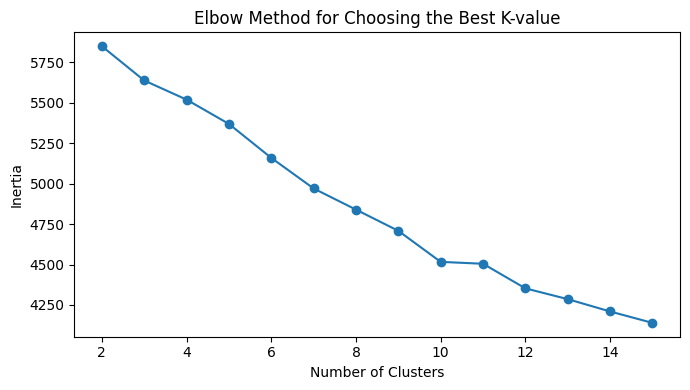

In [64]:
cluster_range = range(2, 16)
inertia_scores = []

for k in cluster_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10 # KMeans will run 10 times with different random starting points, nd keep the best result with the lowest inertia.
    )

    kmeans.fit(X_other_svd)
    inertia_scores.append(kmeans.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(cluster_range), inertia_scores, marker="o")
plt.title("Elbow Method for Choosing the Best K-value")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

In [65]:
# The curve does not show a very sharp elbow, but around k=10
# the improvement starts to slow down, and 10 clusters are still easy to inspect manually.
K_VALUE = 10

# Fit final KMeans model
kmeans_model = KMeans(
    n_clusters=K_VALUE,
    random_state=RANDOM_STATE,
    n_init=10
)

other_df["cluster"] = kmeans_model.fit_predict(X_other_svd)

In [66]:
# Get vocabulary terms from the TF-IDF vectorizer
terms = np.array(other_vectorizer.get_feature_names_out())

for cluster_id in range(K_VALUE):
    cluster_mask = other_df["cluster"] == cluster_id

    # Average TF-IDF score for each word inside this cluster
    cluster_word_scores = np.asarray(
        X_other_tfidf[cluster_mask.values].mean(axis=0)
    ).ravel()

    # Top words for this cluster
    top_word_indices = cluster_word_scores.argsort()[::-1][:8]
    top_words = terms[top_word_indices]

    # Most common MCC descriptions inside this cluster
    top_mccs = (
        other_df.loc[cluster_mask, "mcc_desc"]
        .value_counts()
        .head(3)
        .index
        .tolist()
    )

    # Example merchant descriptions
    examples = (
        other_df.loc[cluster_mask, "desc"]
        .head()
        .tolist()
    )

    print("-" * 80)
    print(f"Cluster {cluster_id}")
    print(f"Size: {cluster_mask.sum():,}")
    print(f"Top words: {', '.join(top_words)}")
    print(f"Top MCCs: {top_mccs}")
    print("Examples:")

    for example in examples:
        print("  -", example)

print("-" * 80)

--------------------------------------------------------------------------------
Cluster 0
Size: 632
Top words: management, company, property, court, road, services, asset, house
Top MCCs: ['Residents property management', 'Management of real estate on a fee or contract basis', 'Management consultancy activities other than financial management']
Examples:
  - r j o'hara project management 
  - 31 belmont road management company 
  - city change management 
  - c m j management 
  - validus risk management 
--------------------------------------------------------------------------------
Cluster 1
Size: 14,306
Top words: holdings, group, construction, property, investments, llp, engineering, design
Top MCCs: ['Other business support service activities n.e.c.', 'unknown', 'Dormant Company']
Examples:
  - m kavanagh 
  - raffall 
  - joio jac 
  - shark's tooth 
  - fresca group 
--------------------------------------------------------------------------------
Cluster 2
Size: 292
Top words:

### Reading the Clusters

Each cluster is summarised using three views: the most important words, the most common MCC descriptions, and a few example merchants. Together, these make the clusters easier to understand.

The results show that the `other` class is not one single group. It contains several recognisable merchant types, such as property companies, consultancy firms, management businesses, development companies, services, and general holdings/groups.

Some clusters are very clear, for example those around `consulting`, `consultancy`, `developments`, and `properties`. The largest cluster is broader and more mixed, which is expected because `other` is a catch-all class.

Some clear themes appear in the clusters:

- **Property and Real Estate**: clusters with words like `property`, `properties`, `developments`, `real estate`, and `building`
- **Consulting and Management**: clusters with words like `consulting`, `consultancy`, `management`, and `business`
- **Business Services**: clusters with words like `services`, `solutions`, `support`, and `financial`



#### **How This Can Be Used**

Clustering can help in three ways:

1. **Discover:** Find hidden groups of merchants inside the `other` class.

2. **Prioritise:** Identify large or clear groups that may be important enough to become new labels.

3. **Extend:** Manually label those groups and add them to the model so it can classify more merchant types in the future.

The MCC field is also a useful baseline because it already provides an industry category. Grouping `other` by MCC can give an immediate segmentation without modelling. However, clustering on `desc` can find patterns that are more specific than MCC, especially when merchants share similar names or business types.
